In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

# Model
import suffix_pred.models.C_LSTM
importlib.reload(suffix_pred.models.C_LSTM)
from suffix_pred.models.C_LSTM import FullShared_Join_LSTM

In [2]:
# Model
file_path_model = '../../trainer/Helpdesk/Helpdesk_C_LSTM_v1.pkl'
model = FullShared_Join_LSTM.load(file_path_model)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../data/Helpdesk/tensor_data/normal/helpdesk_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Data set categories:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Model input features:  [['Activity', 'Resource'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(15, 7)
  (1): Embedding(24, 9)
)
Total embedding feature size:  16
Input feature si

/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [3]:
# --- Step 1: Decode suffixes (mode / arg-max) ---
config = DecodingConfig(concept_name="Activity",
                        eos_value="EOS")

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "mode"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path="helpdesk_c_lstm_mode_outputs.pkl",
                         reuse_cache=False)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# --- Step 2: Evaluate DLS from decoded outputs ---
mode_df = evaluate_dls(outputs)
mode_per_prefix = dls_per_prefix_length(mode_df)
mode_avg = average_dls(mode_df)

print(f"Average DLS ({mode}) on full test set: {mode_avg:.4f}")

  0%|          | 0/916 [00:00<?, ?it/s]

Decoded 3343 prefix rows in 'mode' mode
Average DLS (mode) on full test set: 0.6993


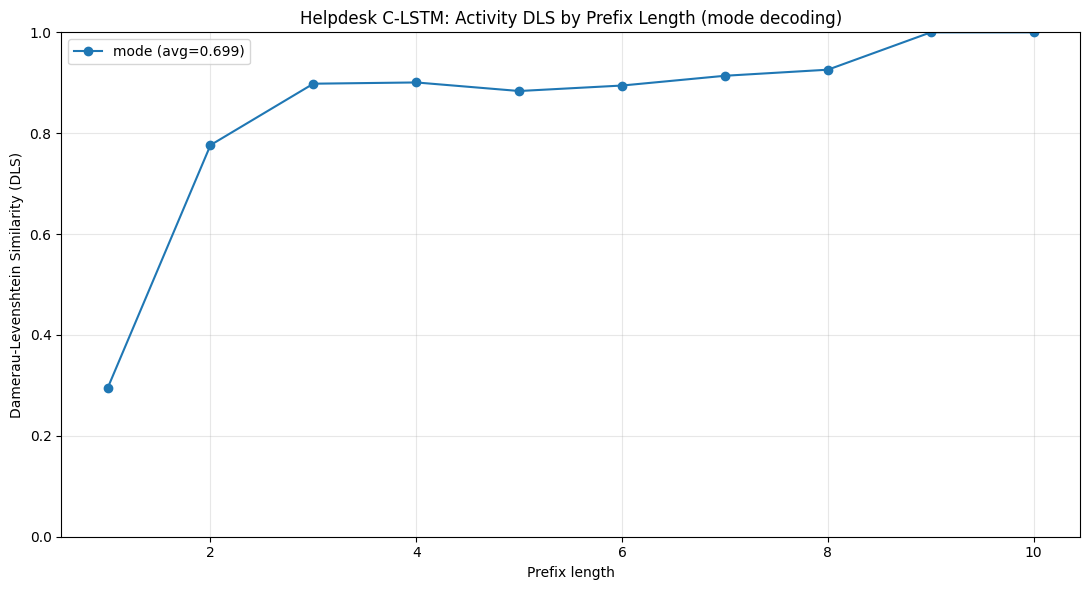

,mode,average_dls
0,mode,0.699277


In [4]:
# ---------------------------
# One combined plot (single method requested: mode decoding only)
# ---------------------------
plt.figure(figsize=(11, 6))

plt.plot(mode_per_prefix["prefix_len"],
         mode_per_prefix["dls"],
         marker="o",
         label=f"mode (avg={mode_avg:.3f})")

plt.title("Helpdesk C-LSTM: Activity DLS by Prefix Length (mode decoding)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({"mode": [mode], "average_dls": [mode_avg]}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [5]:
# Load decoded outputs from pickle and inspect 5 example prefixes
from suffix_pred.evalaution.evalaution_metrics import load_decoded_suffixes

cached_outputs = load_decoded_suffixes("helpdesk_c_lstm_mode_outputs.pkl")

for row in cached_outputs[:5]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row["decoded_suffixes"]
    print(f"  Predicted suffix:  {decoded[0] if len(decoded) > 0 else []}")
    print()

Case: Case 1003  |  Prefix len: 1
  Prefix:            ['Assign seriousness']
  Target suffix:     ['Take in charge ticket', 'Resolve ticket', 'Closed']
  Predicted suffix:  ['Closed']

Case: Case 1003  |  Prefix len: 2
  Prefix:            ['Assign seriousness', 'Take in charge ticket']
  Target suffix:     ['Resolve ticket', 'Closed']
  Predicted suffix:  ['Resolve ticket', 'Closed']

Case: Case 1003  |  Prefix len: 3
  Prefix:            ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket']
  Target suffix:     ['Closed']
  Predicted suffix:  ['Closed']

Case: Case 1004  |  Prefix len: 1
  Prefix:            ['Assign seriousness']
  Target suffix:     ['Take in charge ticket', 'Resolve ticket', 'Closed']
  Predicted suffix:  ['Closed']

Case: Case 1004  |  Prefix len: 2
  Prefix:            ['Assign seriousness', 'Take in charge ticket']
  Target suffix:     ['Resolve ticket', 'Closed']
  Predicted suffix:  ['Resolve ticket', 'Closed']

